# 07 · Role profiles for the NEXUS DELTA app (Career Intelligence inputs)
**Team DSA · NEXUS DELTA · Build for Bharat 2.0 Round 2**  
Run top-to-bottom (Colab: Runtime → Run all). Notebooks 01→06 share files in `out/`.

In [1]:
import os, json, re, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
# ---- Colab: upload the 4 organiser files to /content (left sidebar) or mount Drive and change DATA_DIR ----
DATA_DIR = "."
os.makedirs("figs", exist_ok=True); os.makedirs("out", exist_ok=True)
RES = "out/results.json"
def save_res(key, val):
    r = json.load(open(RES)) if os.path.exists(RES) else {}
    r[key] = val
    json.dump(r, open(RES, "w"), indent=1, default=float)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})
C = {"navy": "#12355b", "teal": "#1b998b", "amber": "#e09f3e", "red": "#c8553d", "grey": "#8d99ae"}

## 1. Role profiles for the Career Intelligence screens (derived from the real postings — no invented numbers)
For each of five target roles we measure, in the Analytics Jobs postings whose designation matches the role: sample size, capability prevalence (share of postings tagging each capability), the salary-band distribution, experience and location mix. The app reads these; it never recomputes them.

In [2]:
a = pd.read_csv("out/analytics_clean.csv"); DS = pd.read_csv(f"{DATA_DIR}/DataScience_Jobs.csv")
R = json.load(open(RES))
ROLES = {"Data Scientist": r"data scien", "Data Analyst": r"data analy",
         "ML Engineer": r"machine learning|\bml\b|deep learning|\bai\b|computer vision|\bnlp\b",
         "Data Engineer": r"data engineer|big data|\betl\b|data warehouse",
         "Analytics Consultant": r"analytics consultant|consultant.*(analytic|data)|(analytic|data).*consultant"}
DS_TITLES = {"Data Scientist": ["Data Scientist","Senior Data Scientist"], "Data Analyst": ["Data Analyst","Senior Data Analyst"], "ML Engineer": ["Machine Learning Engineer"],
             "Data Engineer": ["Data Engineer","Senior Data Engineer"], "Analytics Consultant": []}
TAX = json.load(open("out/taxonomy.json"))["TAX"]
# capability demand is measured on key_skills + job_description ONLY (designation excluded): the taxonomy also tags titles such as "Data Scientist" as AI & ML, which would make role demand circular
a["_sk"] = (a.key_skills.fillna("") + " " + a.job_description.fillna("")).str.lower()
for k, p in TAX.items(): a[f"sk_{k}"] = a._sk.str.contains(p, regex=True).astype(int)
a["sk_story"] = ((a.sk_viz == 1) | (a.sk_mis == 1)).astype(int)
CAPS = {"big_data":"sk_big_data","maths_stats":"sk_maths_stats","coding":"sk_coding","ai_ml":"sk_ai_ml","story":"sk_story"}
BANDS = ["0to3","3to6","6to10","10to15","15to25","25to50"]
roles = {}
for role, pat in ROLES.items():
    m = a.job_desig.str.lower().str.contains(pat, regex=True); r = a[m]
    for c in ["DS Jobs"]: pass
    dsm = DS[DS.job_title.isin(DS_TITLES[role])]
    for c in ["avg_salary"]: dsm = dsm.assign(**{c: dsm[c].str.replace("L","").astype(float)})
    roles[role] = dict(n_postings=int(len(r)), capability_share={k: float(r[v].mean()) for k, v in CAPS.items()},
        band_share=[float((r.salary_ord==i).mean()) for i in range(6)], pct_ge_10LPA=float((r.salary_ord>=3).mean()*100),
        exp_min_median=float(r.exp_min.median()), tier1_share=float((r.loc_tier=="Tier1").mean()),
        ds_jobs=(dict(rows=int(len(dsm)), median_avg_LPA=float(dsm.avg_salary.median()), median_min_exp=float(dsm.job_title.map(lambda t: 0).sum()*0 + DS[DS.job_title.isin(DS_TITLES[role])].min_experience.median()),
                      postings=int(DS[DS.job_title.isin(DS_TITLES[role])].num_of_jobs.sum())) if len(dsm) else None),
        small_sample=bool(len(r) < 150))
    print(f"{role:21s} n={len(r):5d}  cap share: " + " ".join(f"{k}={v:.2f}" for k, v in roles[role]["capability_share"].items()) + f" | >=10LPA {roles[role]['pct_ge_10LPA']:.0f}% | DS-Jobs median {roles[role]['ds_jobs']['median_avg_LPA'] if roles[role]['ds_jobs'] else 'n/a'}")
save_res("role_profiles", roles)
json.dump(dict(roles=roles, bands=BANDS), open("out/app_artifacts.json","w"), indent=1)

Data Scientist        n=  439  cap share: big_data=0.24 maths_stats=0.42 coding=0.67 ai_ml=0.84 story=0.12 | >=10LPA 71% | DS-Jobs median 16.6
Data Analyst          n=  395  cap share: big_data=0.14 maths_stats=0.31 coding=0.50 ai_ml=0.15 story=0.39 | >=10LPA 40% | DS-Jobs median 6.3
ML Engineer           n=  284  cap share: big_data=0.13 maths_stats=0.22 coding=0.68 ai_ml=0.89 story=0.05 | >=10LPA 79% | DS-Jobs median 9.1
Data Engineer         n=  398  cap share: big_data=0.67 maths_stats=0.07 coding=0.68 ai_ml=0.15 story=0.12 | >=10LPA 65% | DS-Jobs median 14.3
Analytics Consultant  n=  140  cap share: big_data=0.19 maths_stats=0.46 coding=0.49 ai_ml=0.14 story=0.26 | >=10LPA 58% | DS-Jobs median n/a


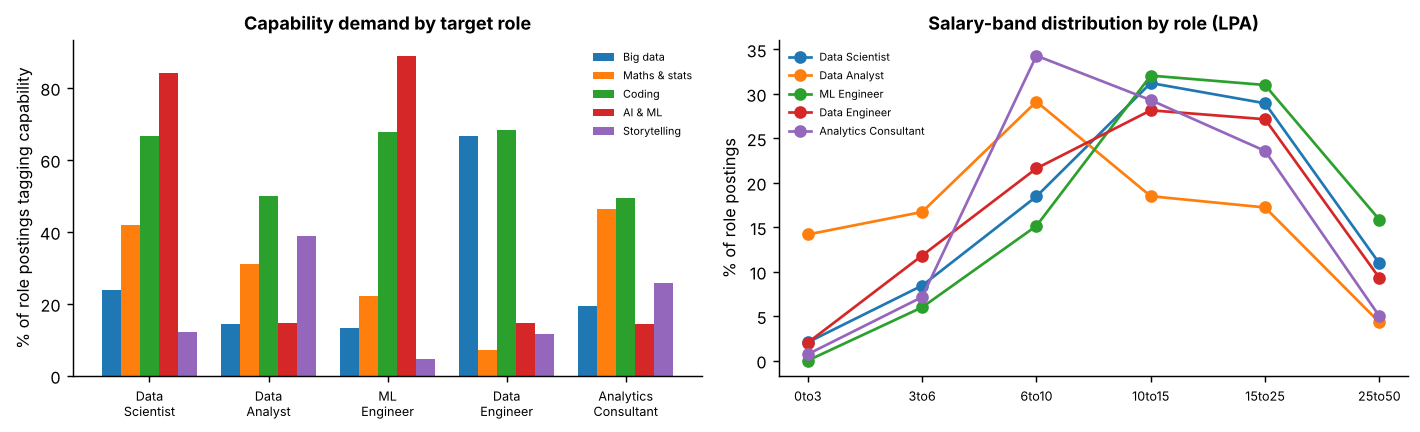

In [3]:
import matplotlib.pyplot as plt
names = list(roles); caps = list(CAPS); lab = {"big_data":"Big data","maths_stats":"Maths & stats","coding":"Coding","ai_ml":"AI & ML","story":"Storytelling"}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4)); w = 0.16
for i, k in enumerate(caps): ax[0].bar(np.arange(len(names)) + (i-2)*w, [roles[n]["capability_share"][k]*100 for n in names], w, label=lab[k])
ax[0].set_xticks(range(len(names))); ax[0].set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=7); ax[0].set_ylabel("% of role postings tagging capability"); ax[0].legend(fontsize=6, frameon=False); ax[0].set_title("Capability demand by target role")
for n in names: ax[1].plot(range(6), [x*100 for x in roles[n]["band_share"]], marker="o", label=n)
ax[1].set_xticks(range(6)); ax[1].set_xticklabels(BANDS, fontsize=7); ax[1].set_ylabel("% of role postings"); ax[1].legend(fontsize=6, frameon=False); ax[1].set_title("Salary-band distribution by role (LPA)")
plt.tight_layout(); plt.savefig("figs/fig08_roles.png", bbox_inches="tight"); plt.show()